In [1]:
import json 
import os
import csv
from pathlib import Path

import SRC
metadata = SRC.load_model_metadata()
from SRC.helpFolder import *

In [11]:
def transform_json_to_csv(json_path, csv_path, room_map):
    """
    Convert a hotel-metrics JSON file to the flattened CSV format.
    Returns both the full DataFrame and a filtered DataFrame without columns for room 168.
    """
    import pandas as pd
    
    if room_map is None:                       
        room_map = {"Standard Room": "166",
                    "Family Room":  "167"}

    with Path(json_path).open(encoding="utf-8") as f:
        data = json.load(f)

    fieldnames = ["date"]
    for code in room_map.values():
        fieldnames += [f"total_price_{code}", f"taux_occupation_{code}"]

    rows = []
    for date, rooms in sorted(data.items()):   
        row = {"date": date}
        for room_name, code in room_map.items():
            info = rooms.get(room_name, {})    
            row[f"total_price_{code}"]     = info.get("Revenue", 0)
            row[f"taux_occupation_{code}"] = info.get("Occupancy percentage", 0)
        rows.append(row)

    with Path(csv_path).open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)
    
    df_full = pd.read_csv(csv_path)
    
    df_filtered = df_full.copy()
    if 'total_price_168' in df_filtered.columns:
        df_filtered.drop(columns=['total_price_168', 'taux_occupation_168'], inplace=True)
    
    return df_full, df_filtered

In [12]:
_, df = transform_json_to_csv(
    metadata['PMSInformation']['final_data_path'],
    metadata['PMSInformation']['final_csv_path'],
    metadata['PMSInformation']['room_map'])

In [13]:
df.head()

,date,total_price_166,taux_occupation_166,total_price_167,taux_occupation_167
0,2024-05-01,14048.16,1.45,0.0,0.00
1,2024-05-02,57342.62,7.00,0.0,0.00
2,2024-05-03,81992.10,11.84,0.0,0.00
3,2024-05-04,167465.61,31.40,4850.0,5.56
4,2024-05-05,175461.31,38.65,6950.0,11.11


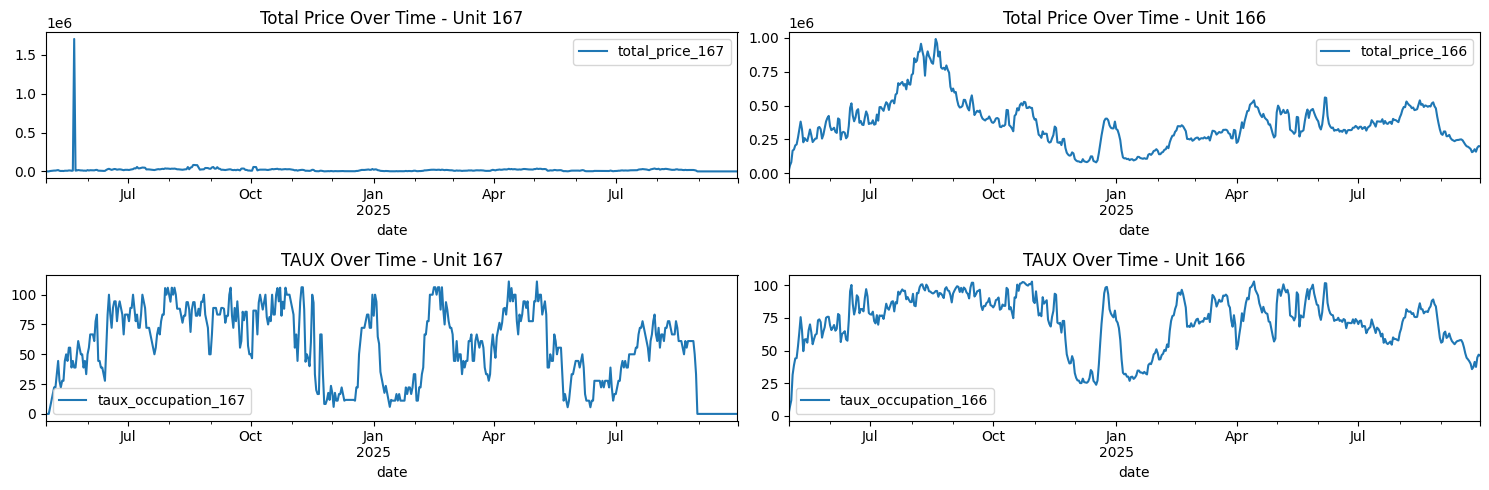

In [14]:
df_167, df_166 = prepare_and_plot_data(
    csv_path = metadata['PMSInformation']['final_csv_path'],
    start_date = metadata['PMSInformation']['start_date_range'],
    end_date = metadata['PMSInformation']['end_date_range']
)

In [15]:
df_167.head()

,dayofweek,month,year,dayofyear,weekofyear,total_price_167,taux_occupation_167
date,,,,,,,
2024-05-01,2,5,2024,122,18,0.0,0.00
2024-05-02,3,5,2024,123,18,0.0,0.00
2024-05-03,4,5,2024,124,18,0.0,0.00
2024-05-04,5,5,2024,125,18,4850.0,5.56
2024-05-05,6,5,2024,126,18,6950.0,11.11


In [18]:
df_167.shape

(518, 7)

In [20]:
df_167.sort_values(by='total_price_167', ascending=False).head(20)

,dayofweek,month,year,dayofyear,weekofyear,total_price_167,taux_occupation_167
date,,,,,,,
2024-05-22,2,5,2024,143,21,1705897.16,38.89
2024-08-20,1,8,2024,233,34,82534.93,93.75
2024-08-19,0,8,2024,232,34,82534.93,93.75
2024-08-22,3,8,2024,235,34,80628.32,82.35
2024-08-21,2,8,2024,234,34,80599.93,82.35
2024-07-08,0,7,2024,190,28,57254.22,83.33
2024-10-03,3,10,2024,277,40,56963.66,86.67
2024-09-03,1,9,2024,247,36,56619.90,88.89
2024-08-15,3,8,2024,228,33,56083.96,93.75


In [16]:
df_167[df_167['total_price_167'] > 0]

,dayofweek,month,year,dayofyear,weekofyear,total_price_167,taux_occupation_167
date,,,,,,,
2024-05-04,5,5,2024,125,18,4850.00,5.56
2024-05-05,6,5,2024,126,18,6950.00,11.11
2024-05-06,0,5,2024,127,19,8470.00,16.67
2024-05-07,1,5,2024,128,19,10570.00,22.22
2024-05-08,2,5,2024,129,19,10570.00,22.22
...,...,...,...,...,...,...,...
2025-08-26,1,8,2025,238,35,18239.48,61.11
2025-08-27,2,8,2025,239,35,18239.48,61.11
2025-08-28,3,8,2025,240,35,18239.48,61.11


In [22]:
df_167.tail()

,dayofweek,month,year,dayofyear,weekofyear,total_price_167,taux_occupation_167
date,,,,,,,
2025-09-26,4,9,2025,269,39,0.0,0.0
2025-09-27,5,9,2025,270,39,0.0,0.0
2025-09-28,6,9,2025,271,39,0.0,0.0
2025-09-29,0,9,2025,272,40,0.0,0.0
2025-09-30,1,9,2025,273,40,0.0,0.0


In [23]:
df_167[df_167['total_price_167'] == 0].head(10)

,dayofweek,month,year,dayofyear,weekofyear,total_price_167,taux_occupation_167
date,,,,,,,
2024-05-01,2,5,2024,122,18,0.0,0.0
2024-05-02,3,5,2024,123,18,0.0,0.0
2024-05-03,4,5,2024,124,18,0.0,0.0
2025-08-31,6,8,2025,243,35,0.0,0.0
2025-09-01,0,9,2025,244,36,0.0,0.0
2025-09-02,1,9,2025,245,36,0.0,0.0
2025-09-03,2,9,2025,246,36,0.0,0.0
2025-09-04,3,9,2025,247,36,0.0,0.0
2025-09-05,4,9,2025,248,36,0.0,0.0


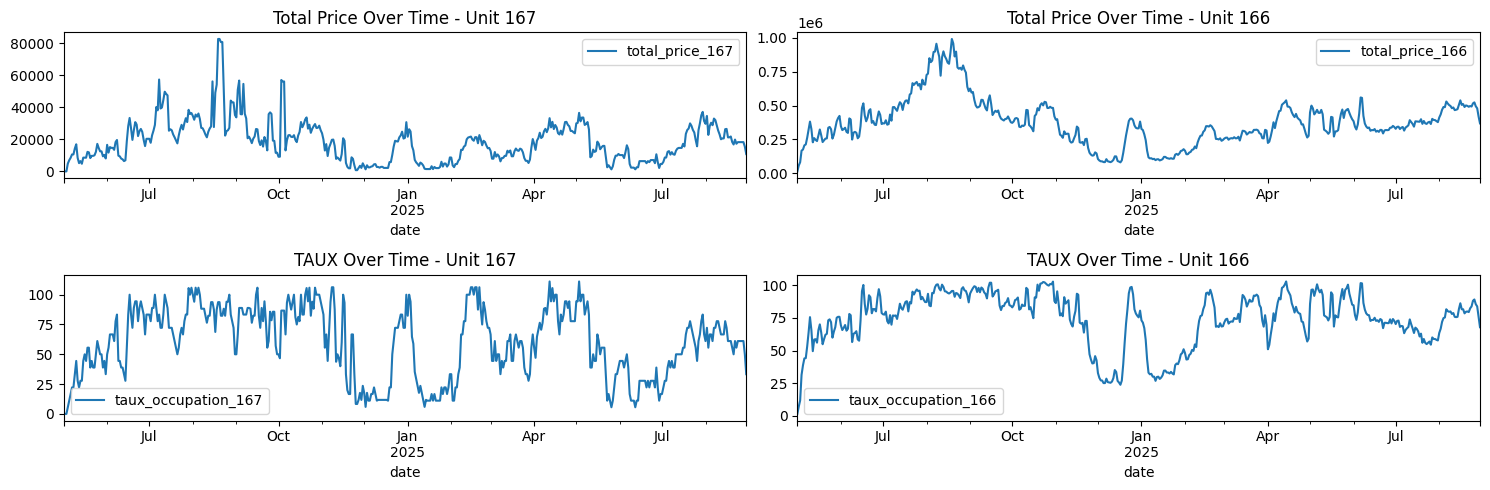

In [2]:
df_167, df_166 = prepare_and_plot_data(
    csv_path = metadata['PMSInformation']['final_csv_path'],
    start_date = metadata['PMSInformation']['start_date_range'],
    end_date = metadata['PMSInformation']['end_date_range']
)